## Notebook for loading data and performing initial analysis.

#### Load Data in the folder

In [2]:
import pandas as pd
from pathlib import Path
import os

# Debug: show where the notebook is running
print("Current working directory:", Path.cwd())
print("Top-level files/folders:", [p.name for p in Path.cwd().iterdir()])

# Try to find the CSV anywhere under the current directory
candidates = list(Path.cwd().rglob('bank-full.csv'))
if candidates:
    csv_path = candidates[0]
    print("Found CSV at:", csv_path)
    # The UCI "bank-full.csv" uses ';' as separator
    df = pd.read_csv(csv_path, sep=';')
else:
    # Fallback: data is in sibling ../data folder (one level up from notebooks)
    alt = Path.cwd().parent / 'data' / 'bank-full.csv'
    if alt.exists():
        print("Found CSV at ../data:", alt)
        df = pd.read_csv(alt, sep=';')
    else:
        raise FileNotFoundError(
            f"bank-full.csv not found. Searched {Path.cwd()} and subfolders.\n"
            "Place the file at '../data/bank-full.csv' (sibling to the notebooks folder) or update the path."
        )


Current working directory: /Users/jorgeinigo/Documents/Trabajo final/notebooks
Top-level files/folders: ['main.ipynb', 'mlp_architecture']
Found CSV at ../data: /Users/jorgeinigo/Documents/Trabajo final/data/bank-full.csv


In [3]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


### EDA: Exploratory Data Analysis

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [5]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')

DATASET SHAPE
(45211, 17)

FIRST 5 ROWS


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



DATA TYPES AND MISSING VALUES
<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB


None


NUMERICAL SUMMARY


...


CATEGORICAL SUMMARY


/var/folders/9h/1d85mprx2xn1040st4mrmbqh0000gn/T/ipykernel_21851/925075140.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_summary_cols = df.select_dtypes(include=["object", "category", "bool"]).columns


,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922



MISSING VALUES


Series([], dtype: int64)

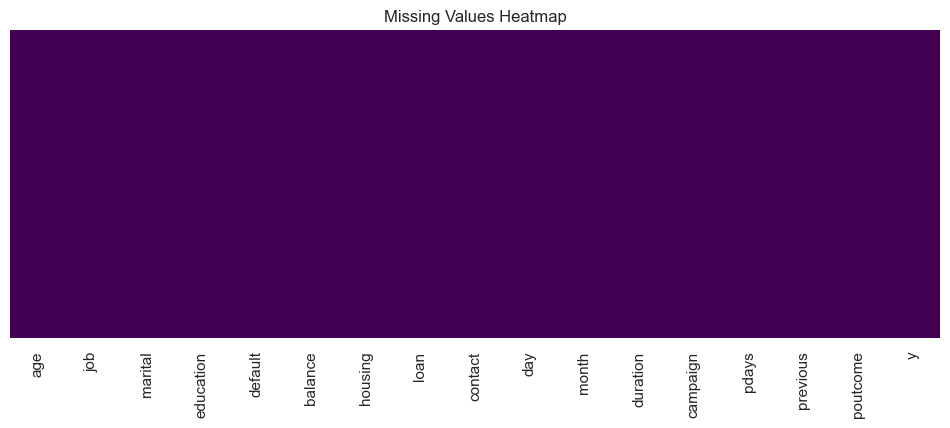

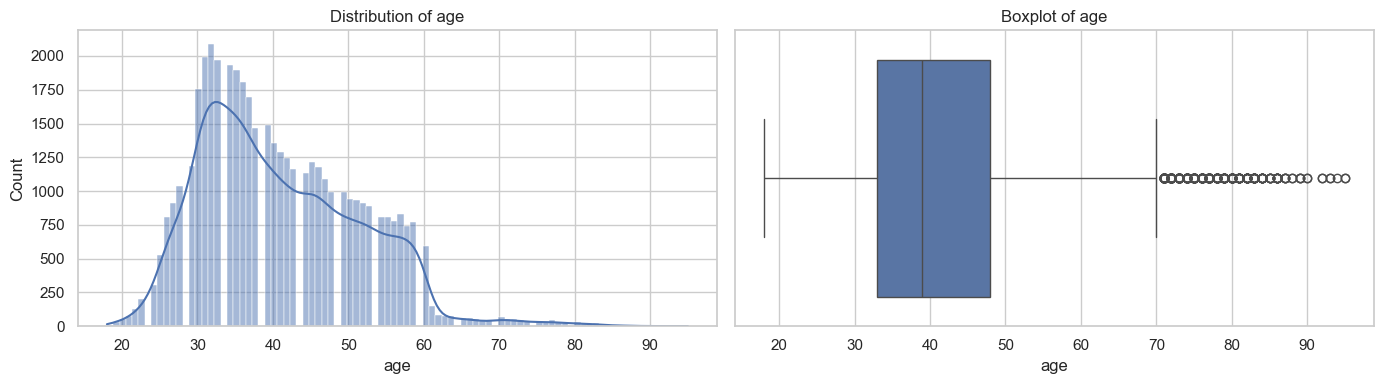

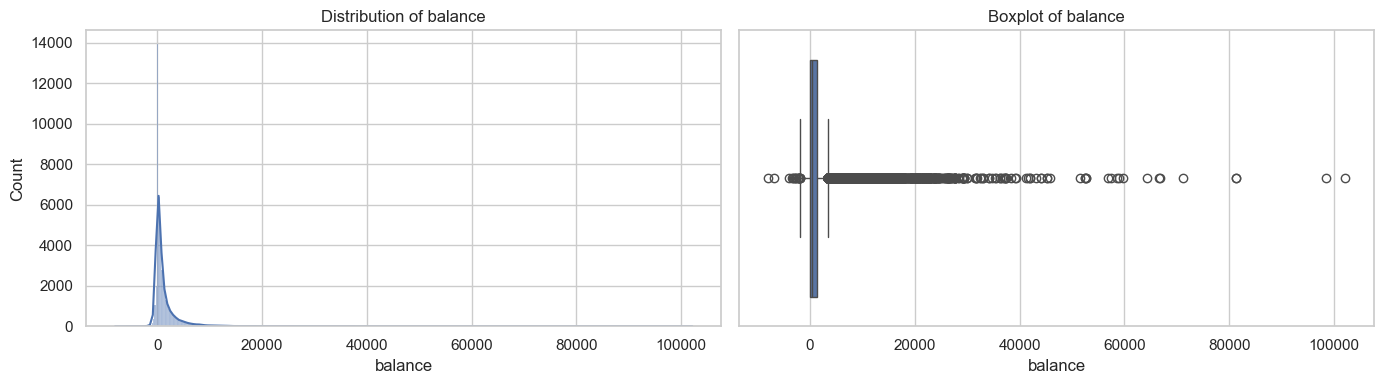

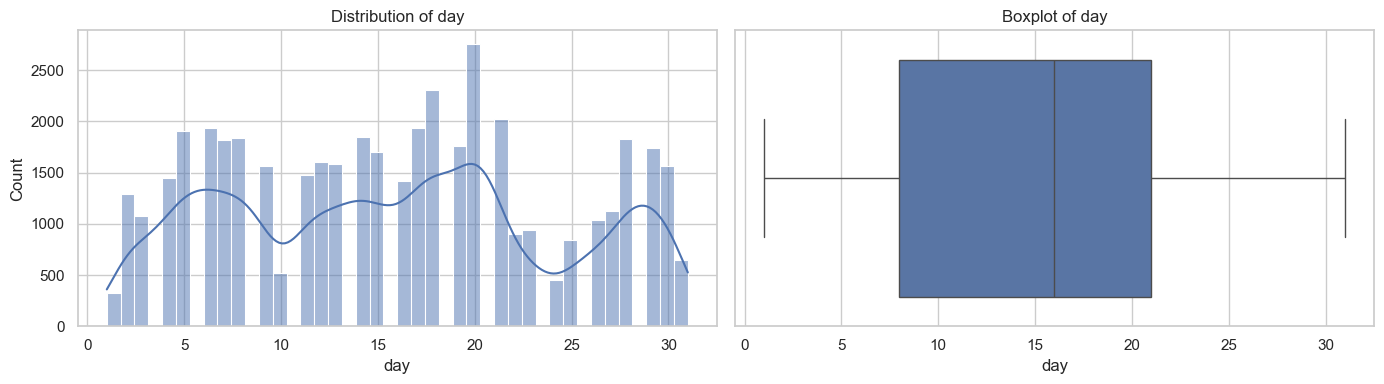

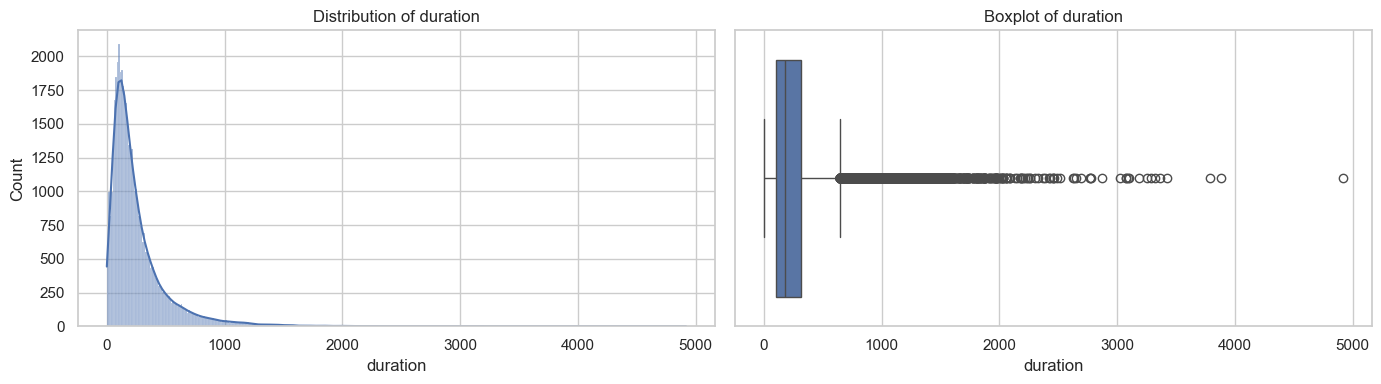

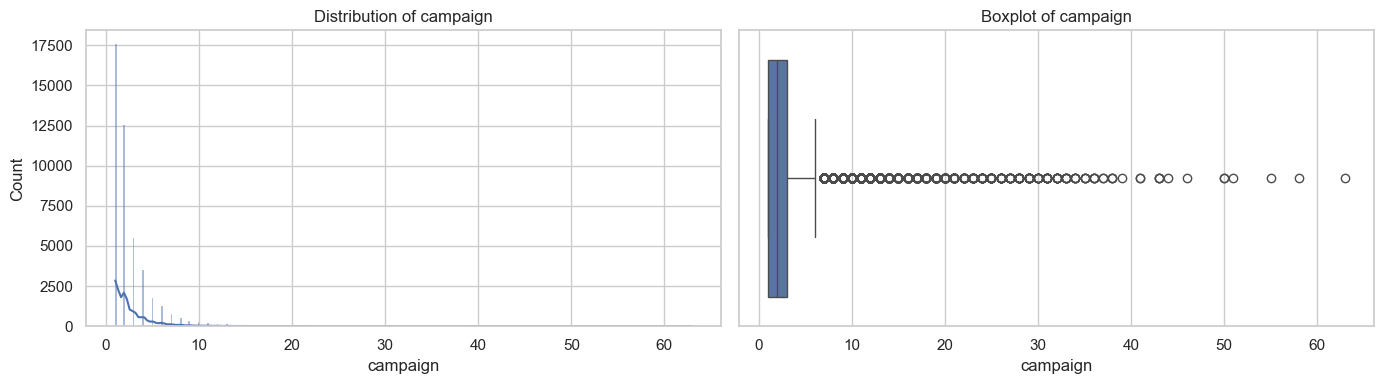

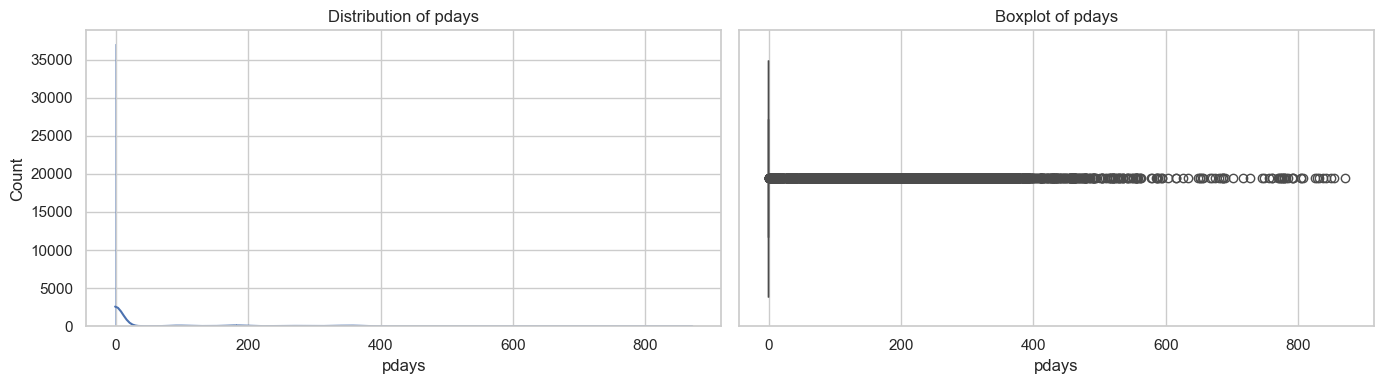

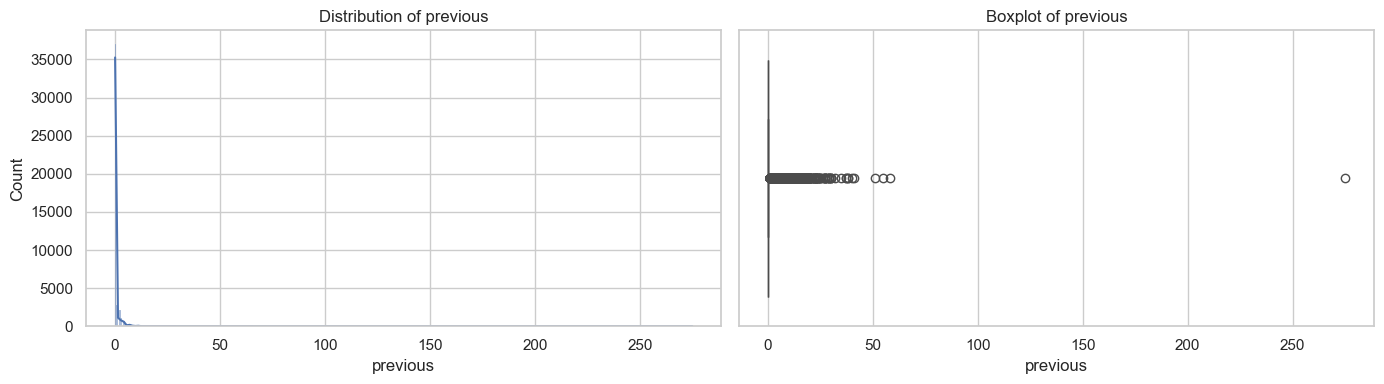

/var/folders/9h/1d85mprx2xn1040st4mrmbqh0000gn/T/ipykernel_21851/925075140.py:65: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns


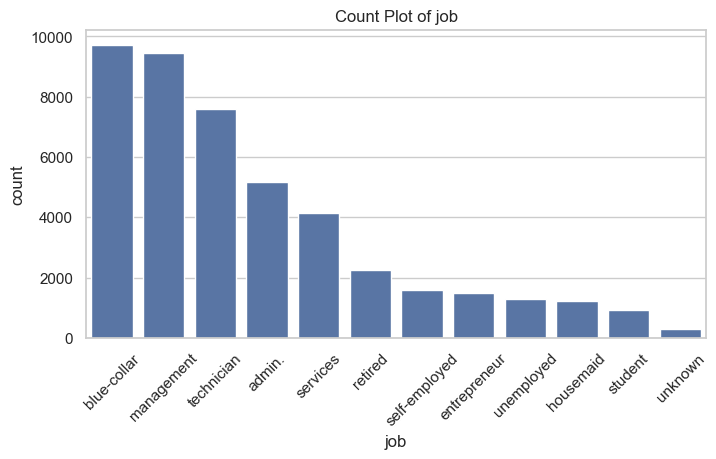

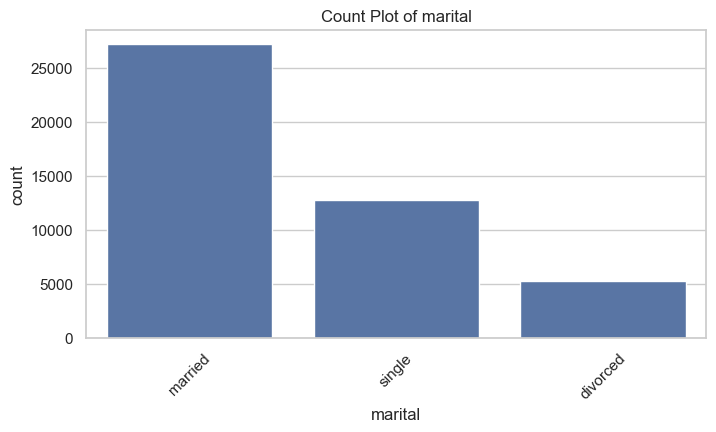

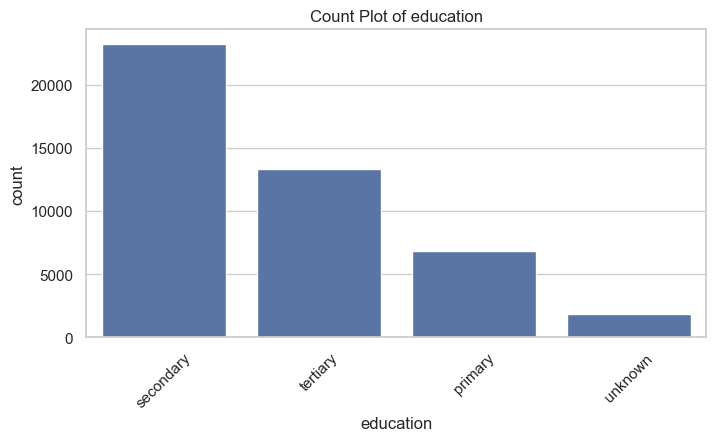

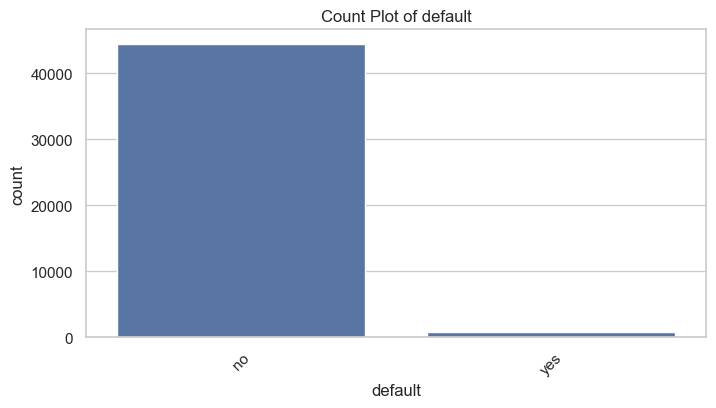

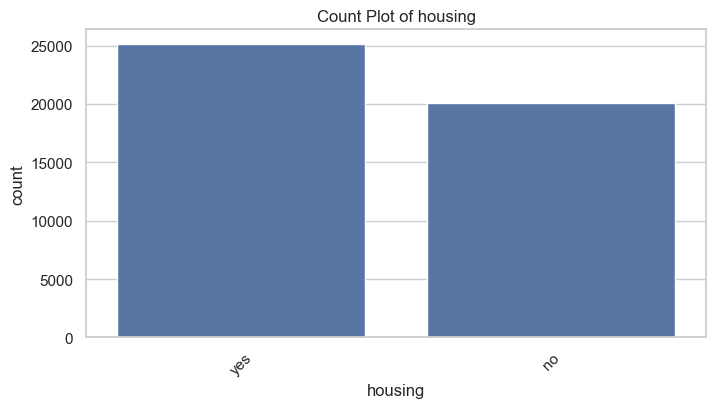

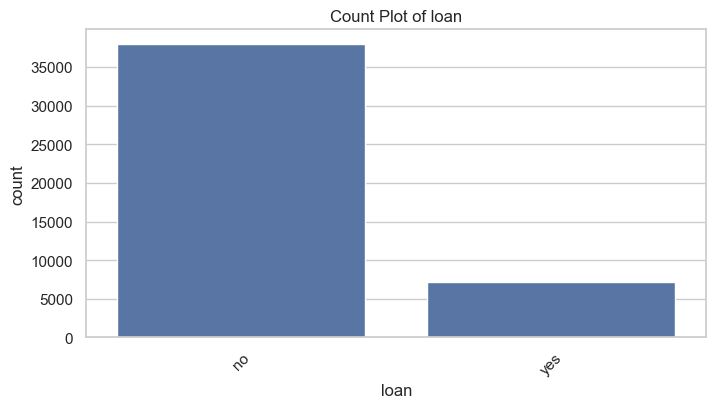

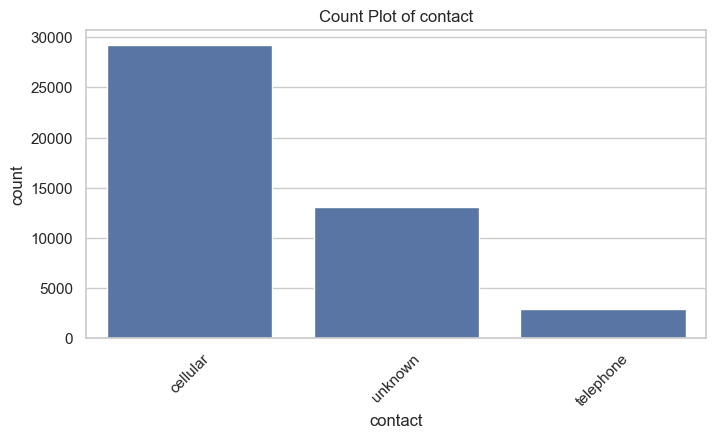

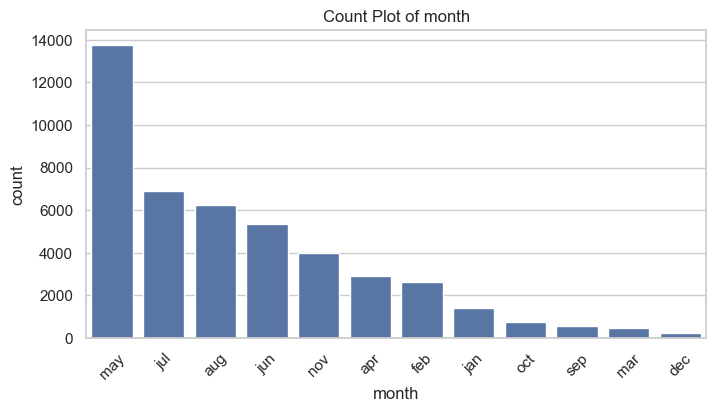

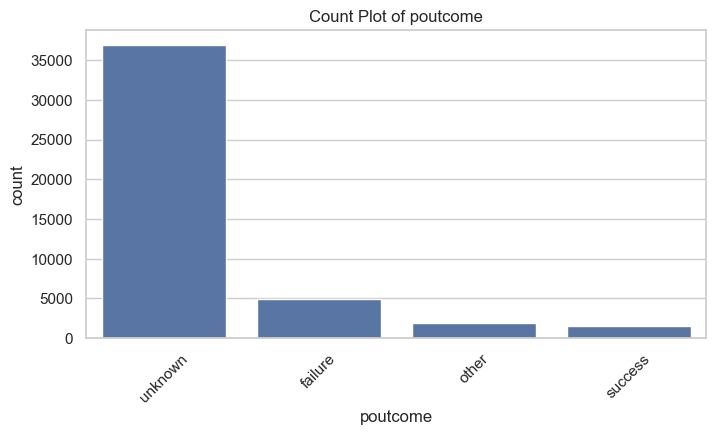

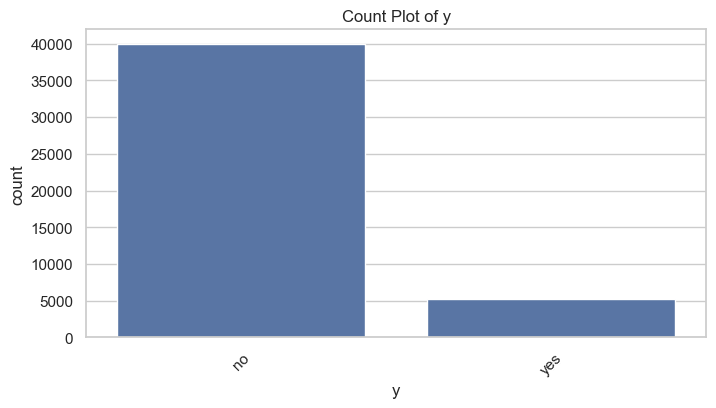

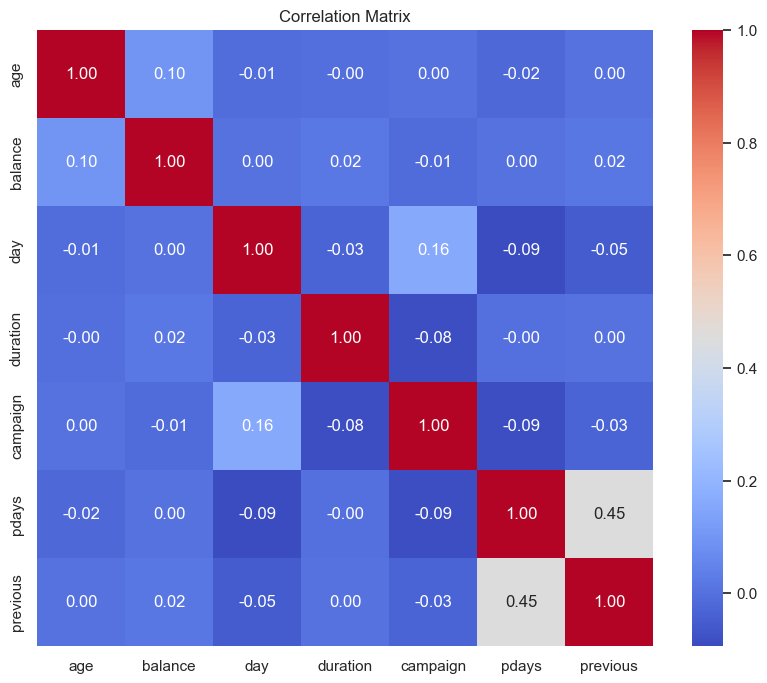

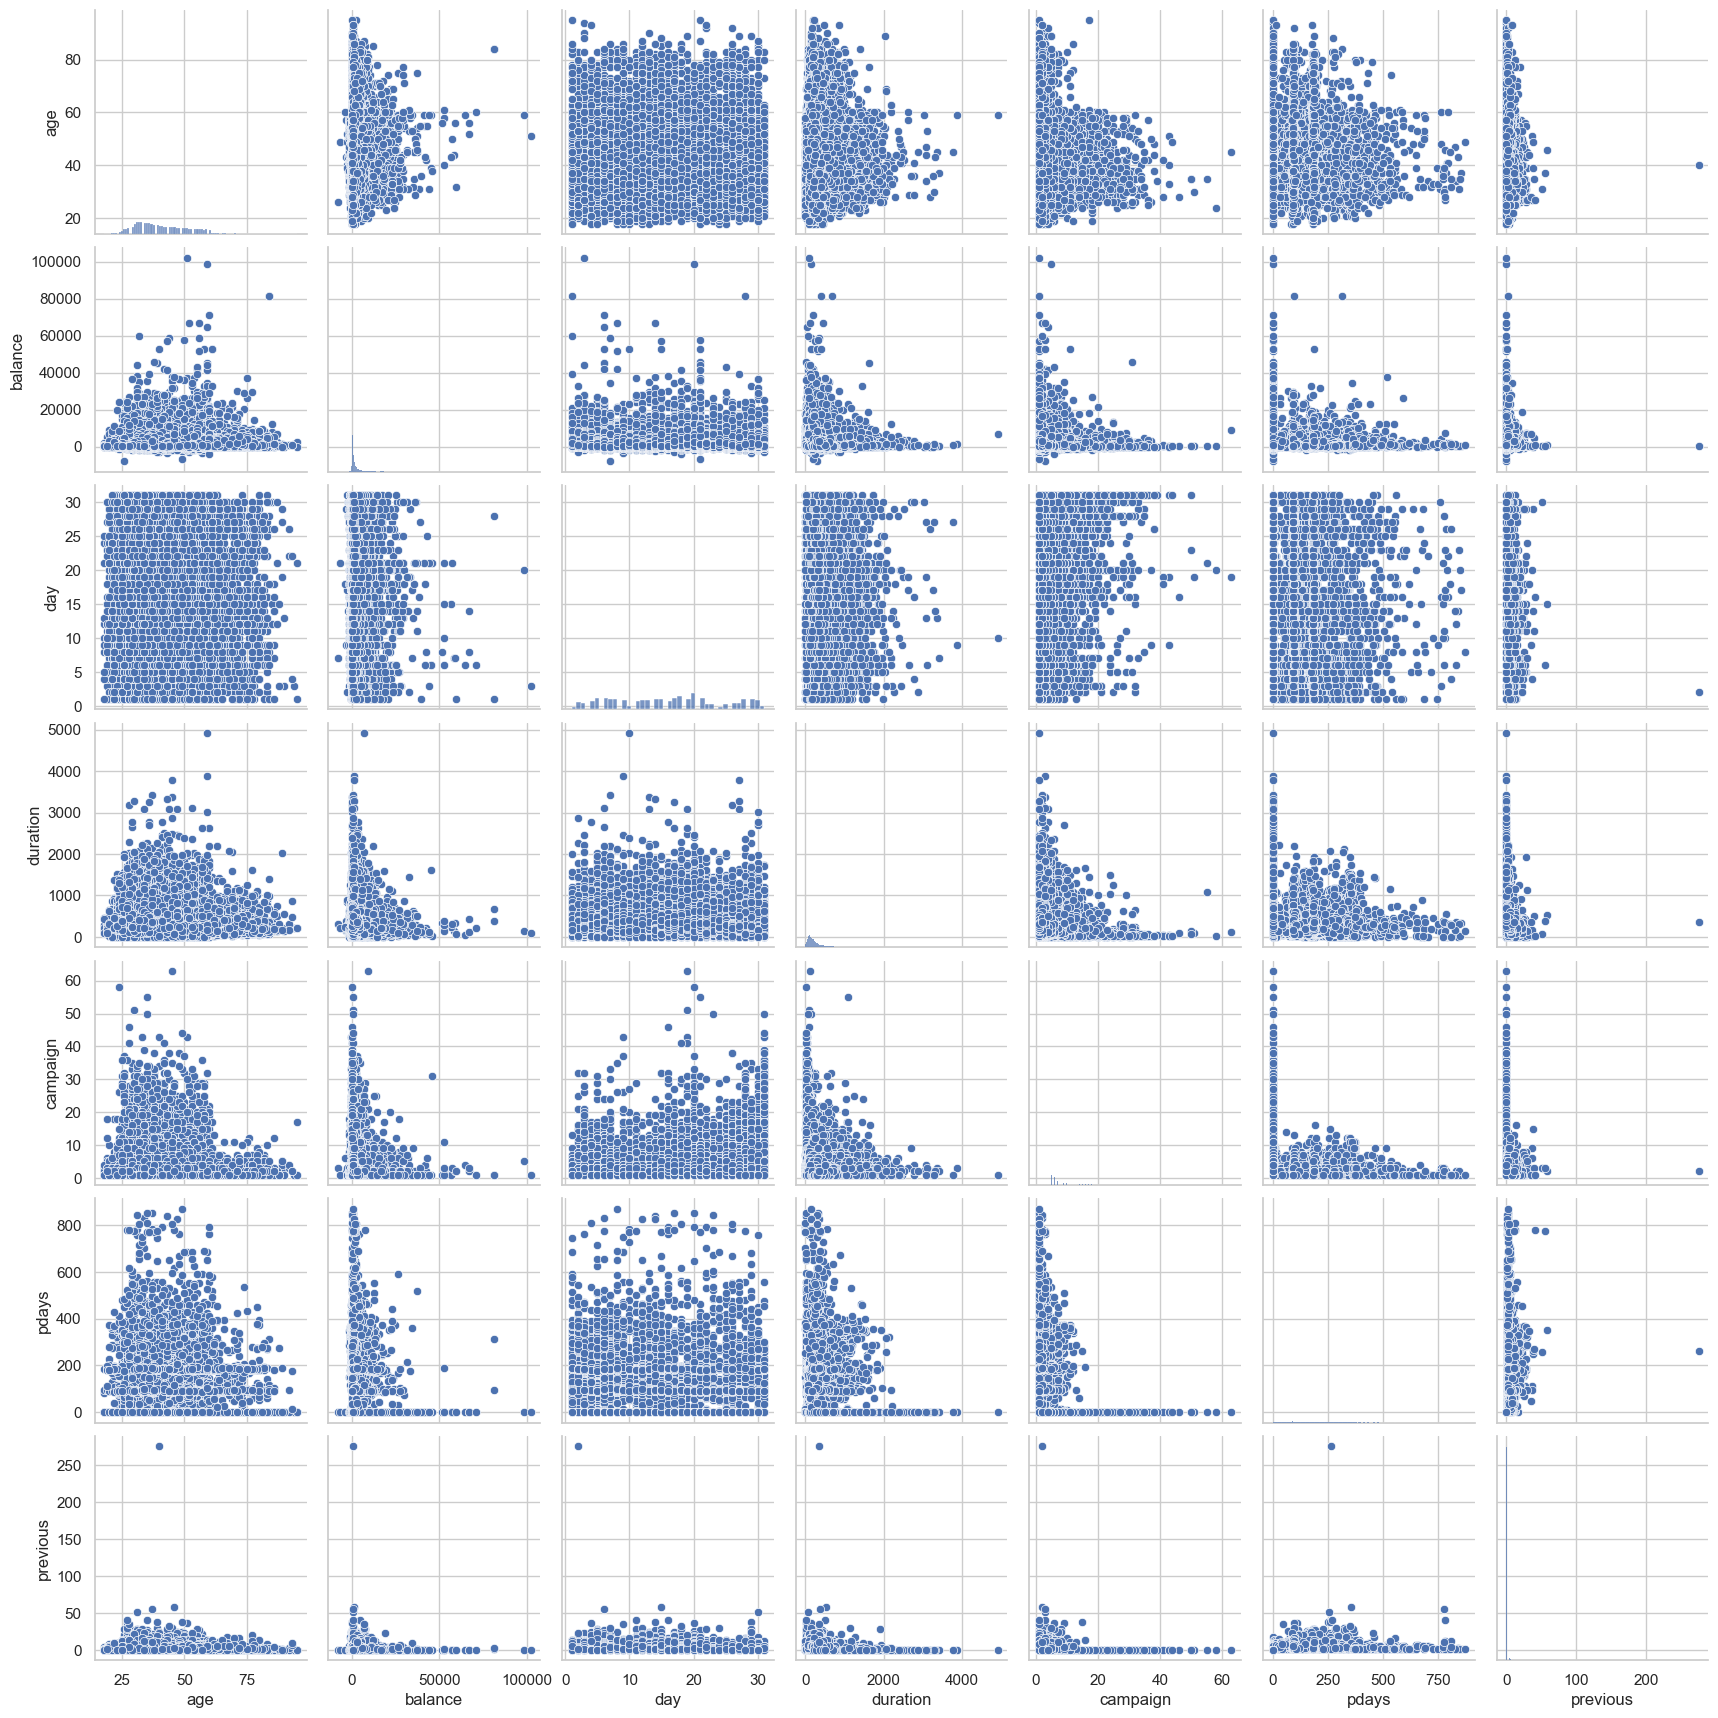


FAST EDA COMPLETED


In [6]:
# =========================
# FAST EDA IN ONE CELL
# =========================

plt.rcParams["figure.figsize"] = (10, 5)

# ---- BASIC INFORMATION ----
print("="*60)
print("DATASET SHAPE")
print("="*60)
print(df.shape)

print("\n" + "="*60)
print("FIRST 5 ROWS")
print("="*60)
display(df.head())

print("\n" + "="*60)
print("DATA TYPES AND MISSING VALUES")
print("="*60)
display(df.info())

print("\n" + "="*60)
print("NUMERICAL SUMMARY")
print("="*60)
display(df.describe())

print("\n" + "="*60)
print("CATEGORICAL SUMMARY")
print("="*60)
cat_summary_cols = df.select_dtypes(include=["object", "category", "bool"]).columns
if len(cat_summary_cols) > 0:
    display(df[cat_summary_cols].describe())
else:
    print("No categorical columns found for describe(include='object').")

# ---- MISSING VALUES ----
print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0])

plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

# ---- NUMERICAL DISTRIBUTIONS ----
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.histplot(df[col].dropna(), kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")

    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

# ---- CATEGORICAL VARIABLES ----
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

# ---- CORRELATION MATRIX ----
if len(num_cols) > 1:
    plt.figure(figsize=(10, 8))
    corr = df[num_cols].corr()

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        square=True
    )
    plt.title("Correlation Matrix")
    plt.show()

# ---- PAIRPLOT ----
if len(num_cols) <= 10:
    sns.pairplot(df[num_cols].dropna())
    plt.show()

print("\n" + "="*60)
print("FAST EDA COMPLETED")
print("="*60)

Since the dataset do not have an specific train/test we will define train as 80% of the data randomly selected, 10% as a validation set and 10% as the test set

In [7]:
# Split the dataset into three sets: train, validation and test

df_train = df.sample(frac=0.8, random_state=42)
df_remaining = df.drop(df_train.index)
df_val = df_remaining.sample(frac=0.5, random_state=42)
df_test = df_remaining.drop(df_val.index)

DATASET SHAPE
(45211, 17)

FIRST 5 ROWS


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



DATA TYPES AND MISSING VALUES
<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB


None


NUMERICAL SUMMARY


...


CATEGORICAL SUMMARY


/var/folders/9h/1d85mprx2xn1040st4mrmbqh0000gn/T/ipykernel_21851/3901342096.py:35: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_summary_cols = df.select_dtypes(include=["object", "category", "bool"]).columns


,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922



MISSING VALUES


Series([], dtype: int64)

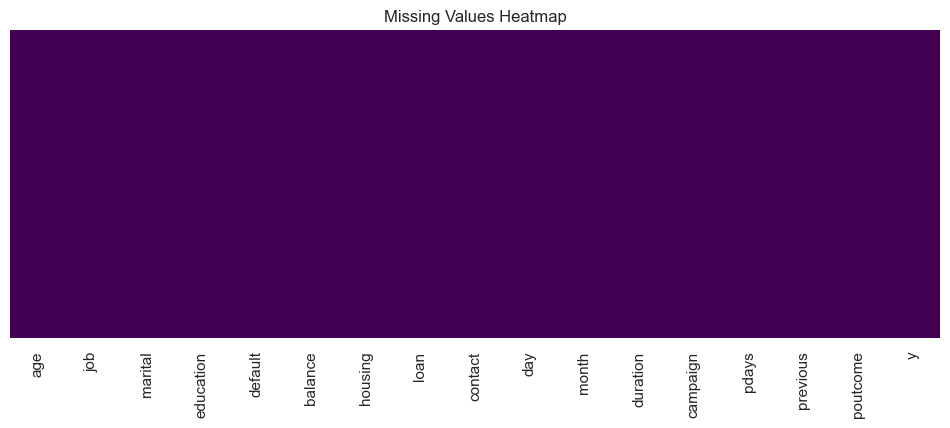

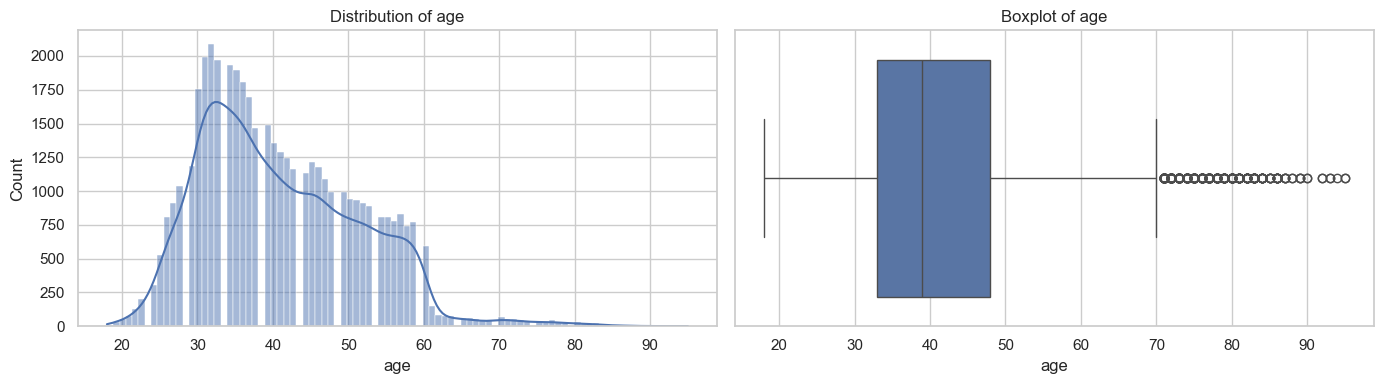

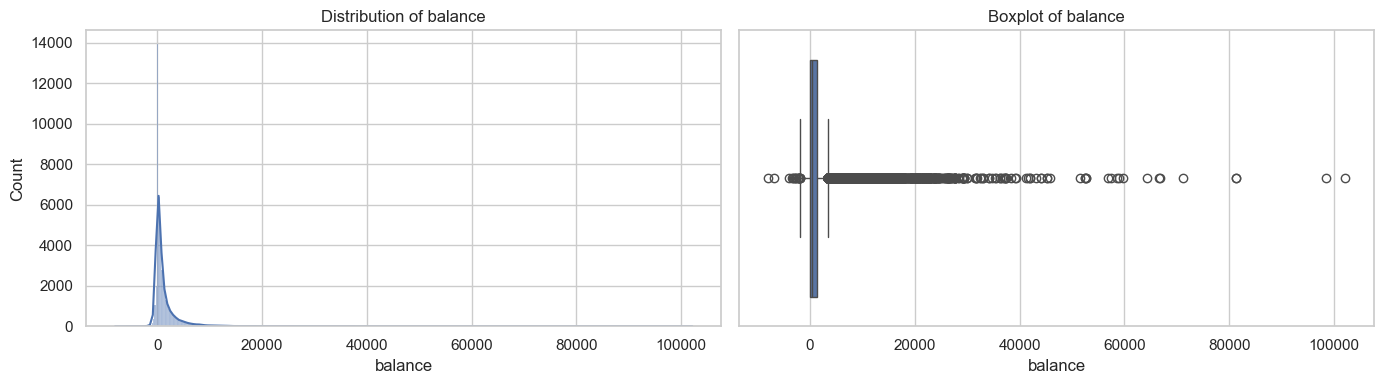

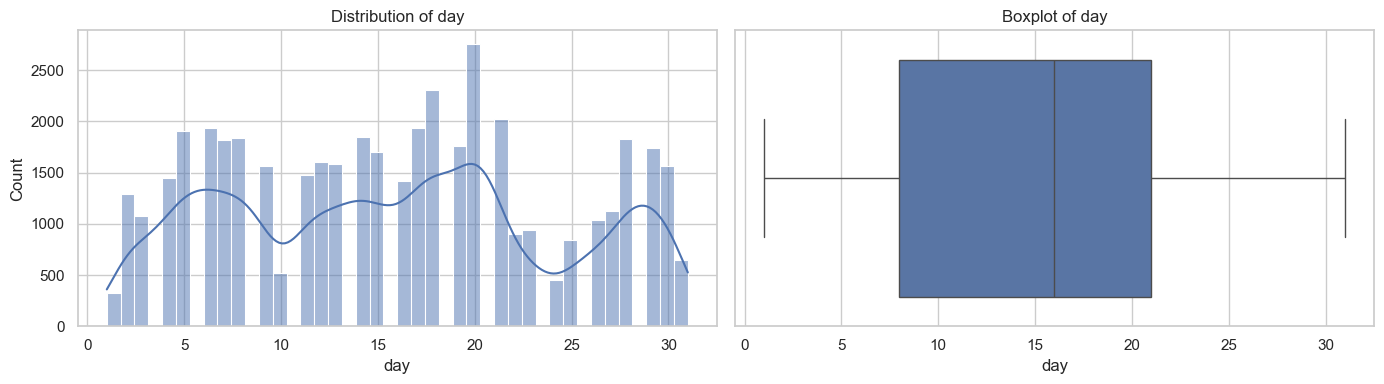

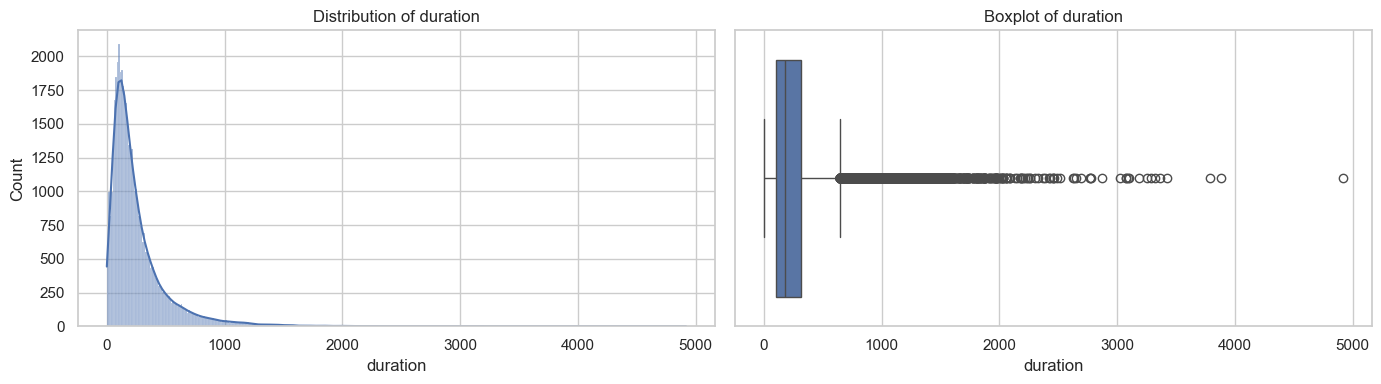

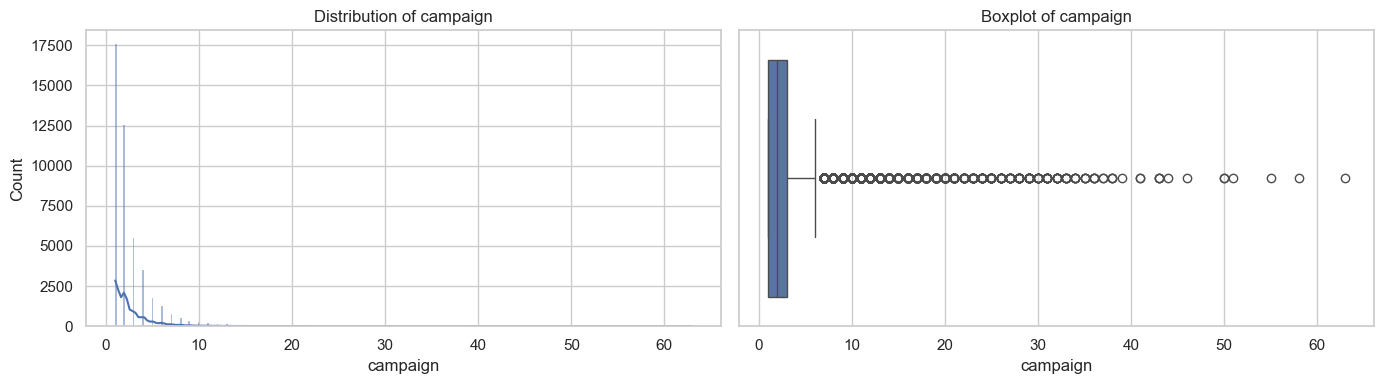

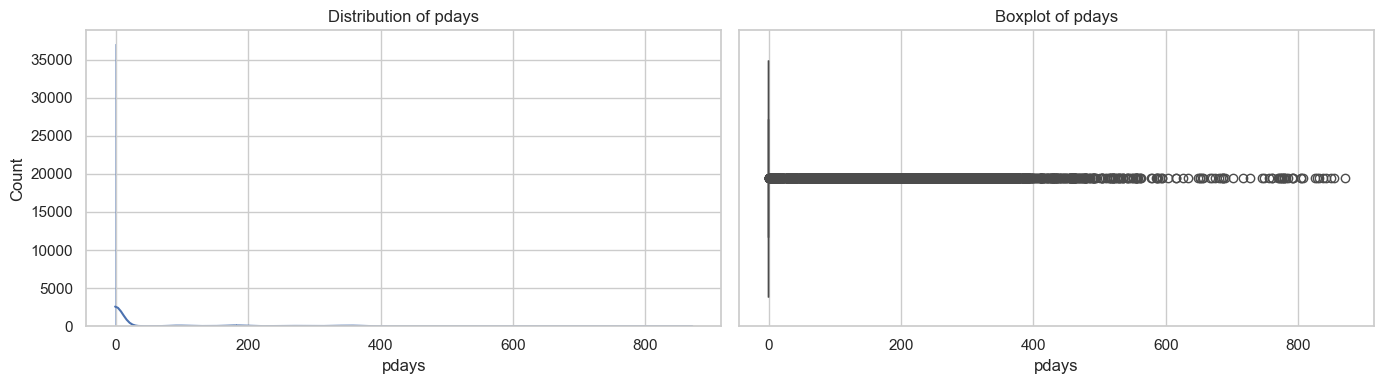

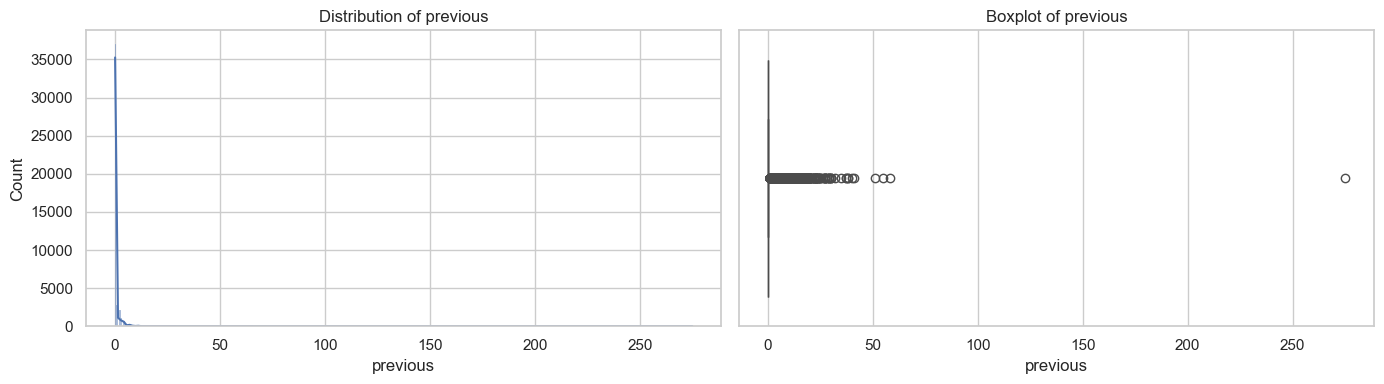

/var/folders/9h/1d85mprx2xn1040st4mrmbqh0000gn/T/ipykernel_21851/3901342096.py:69: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns


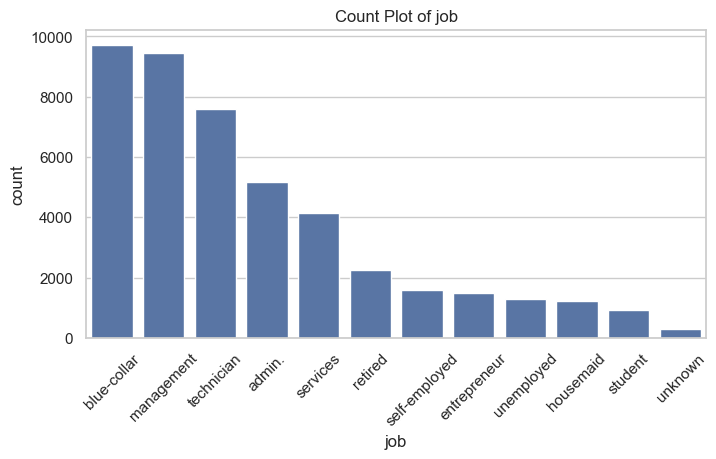

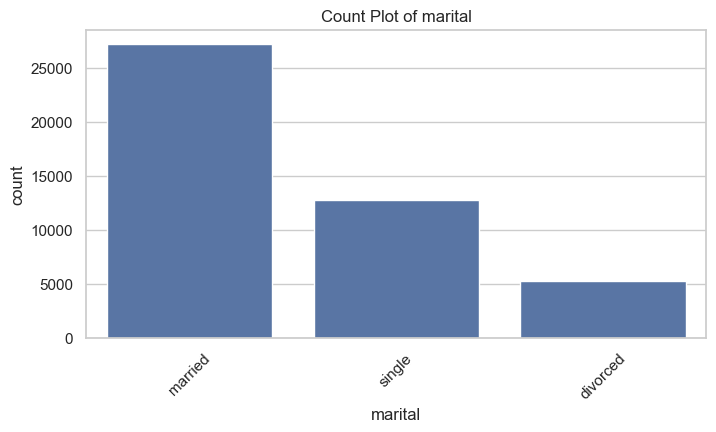

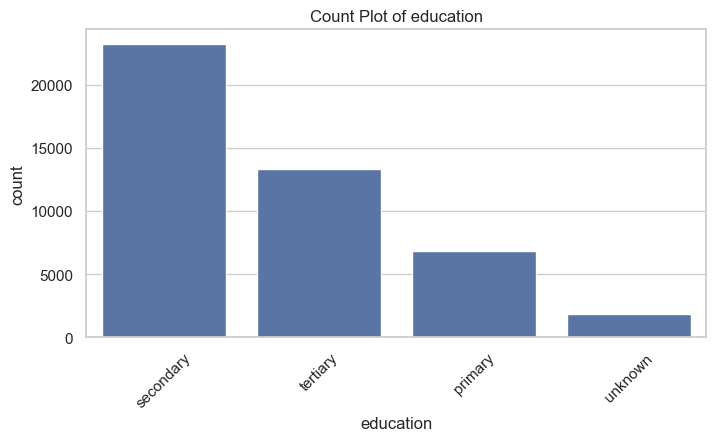

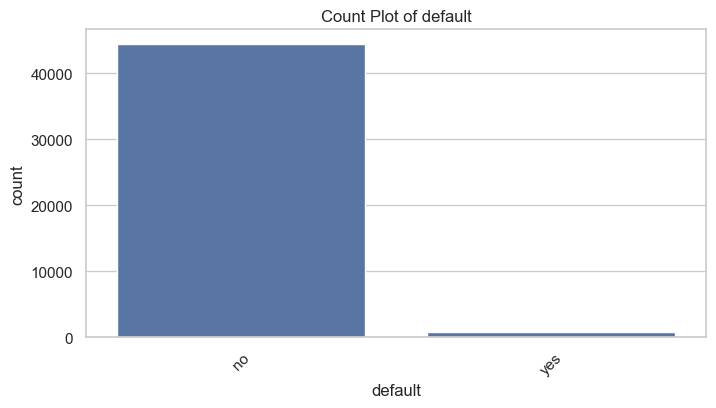

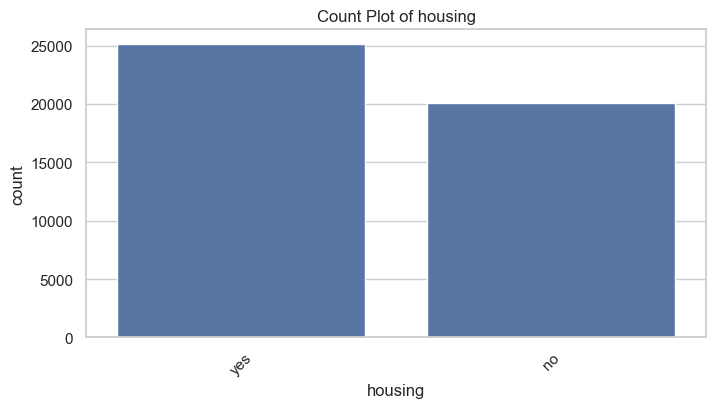

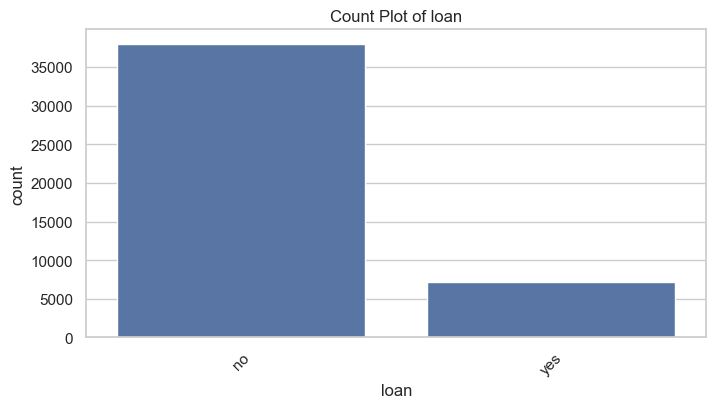

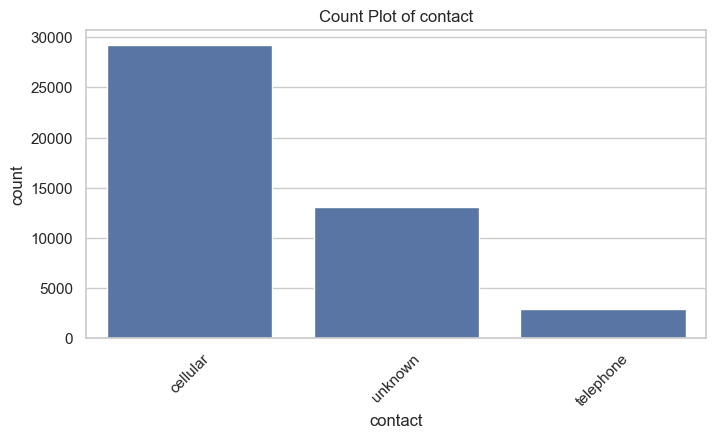

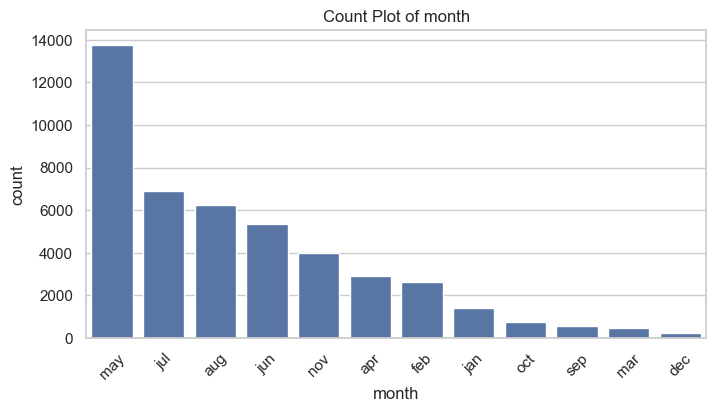

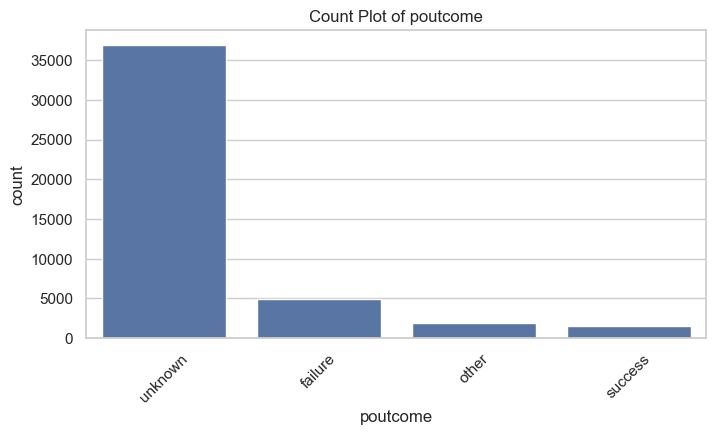

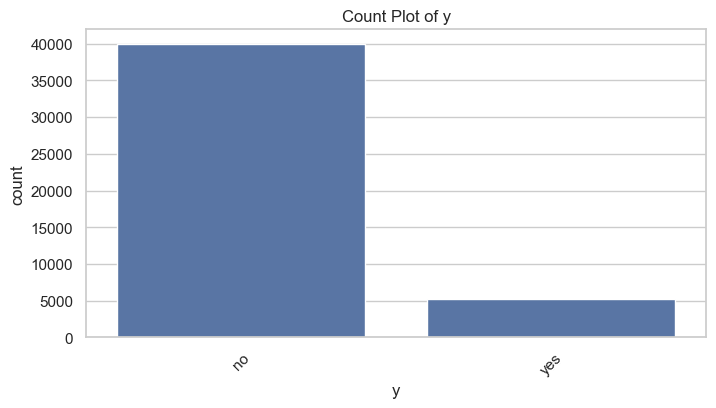

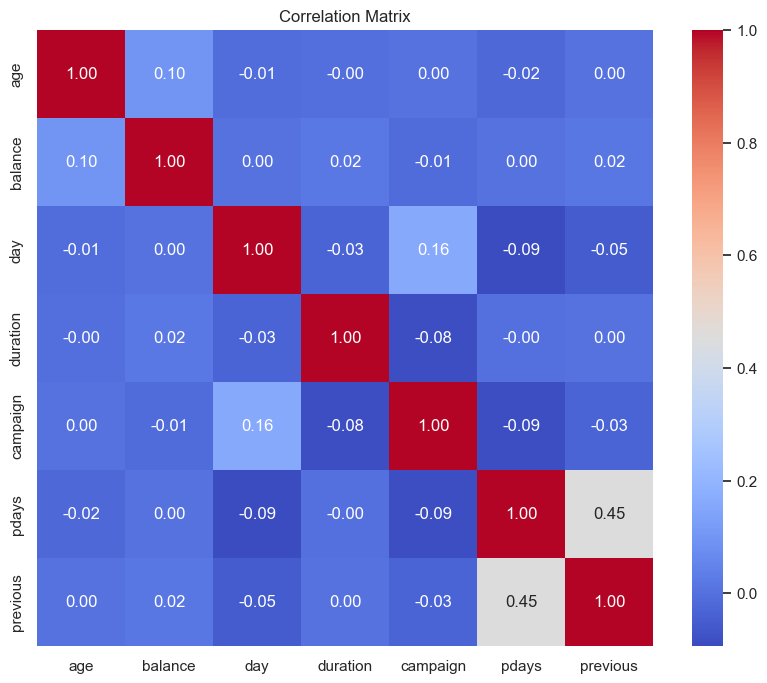

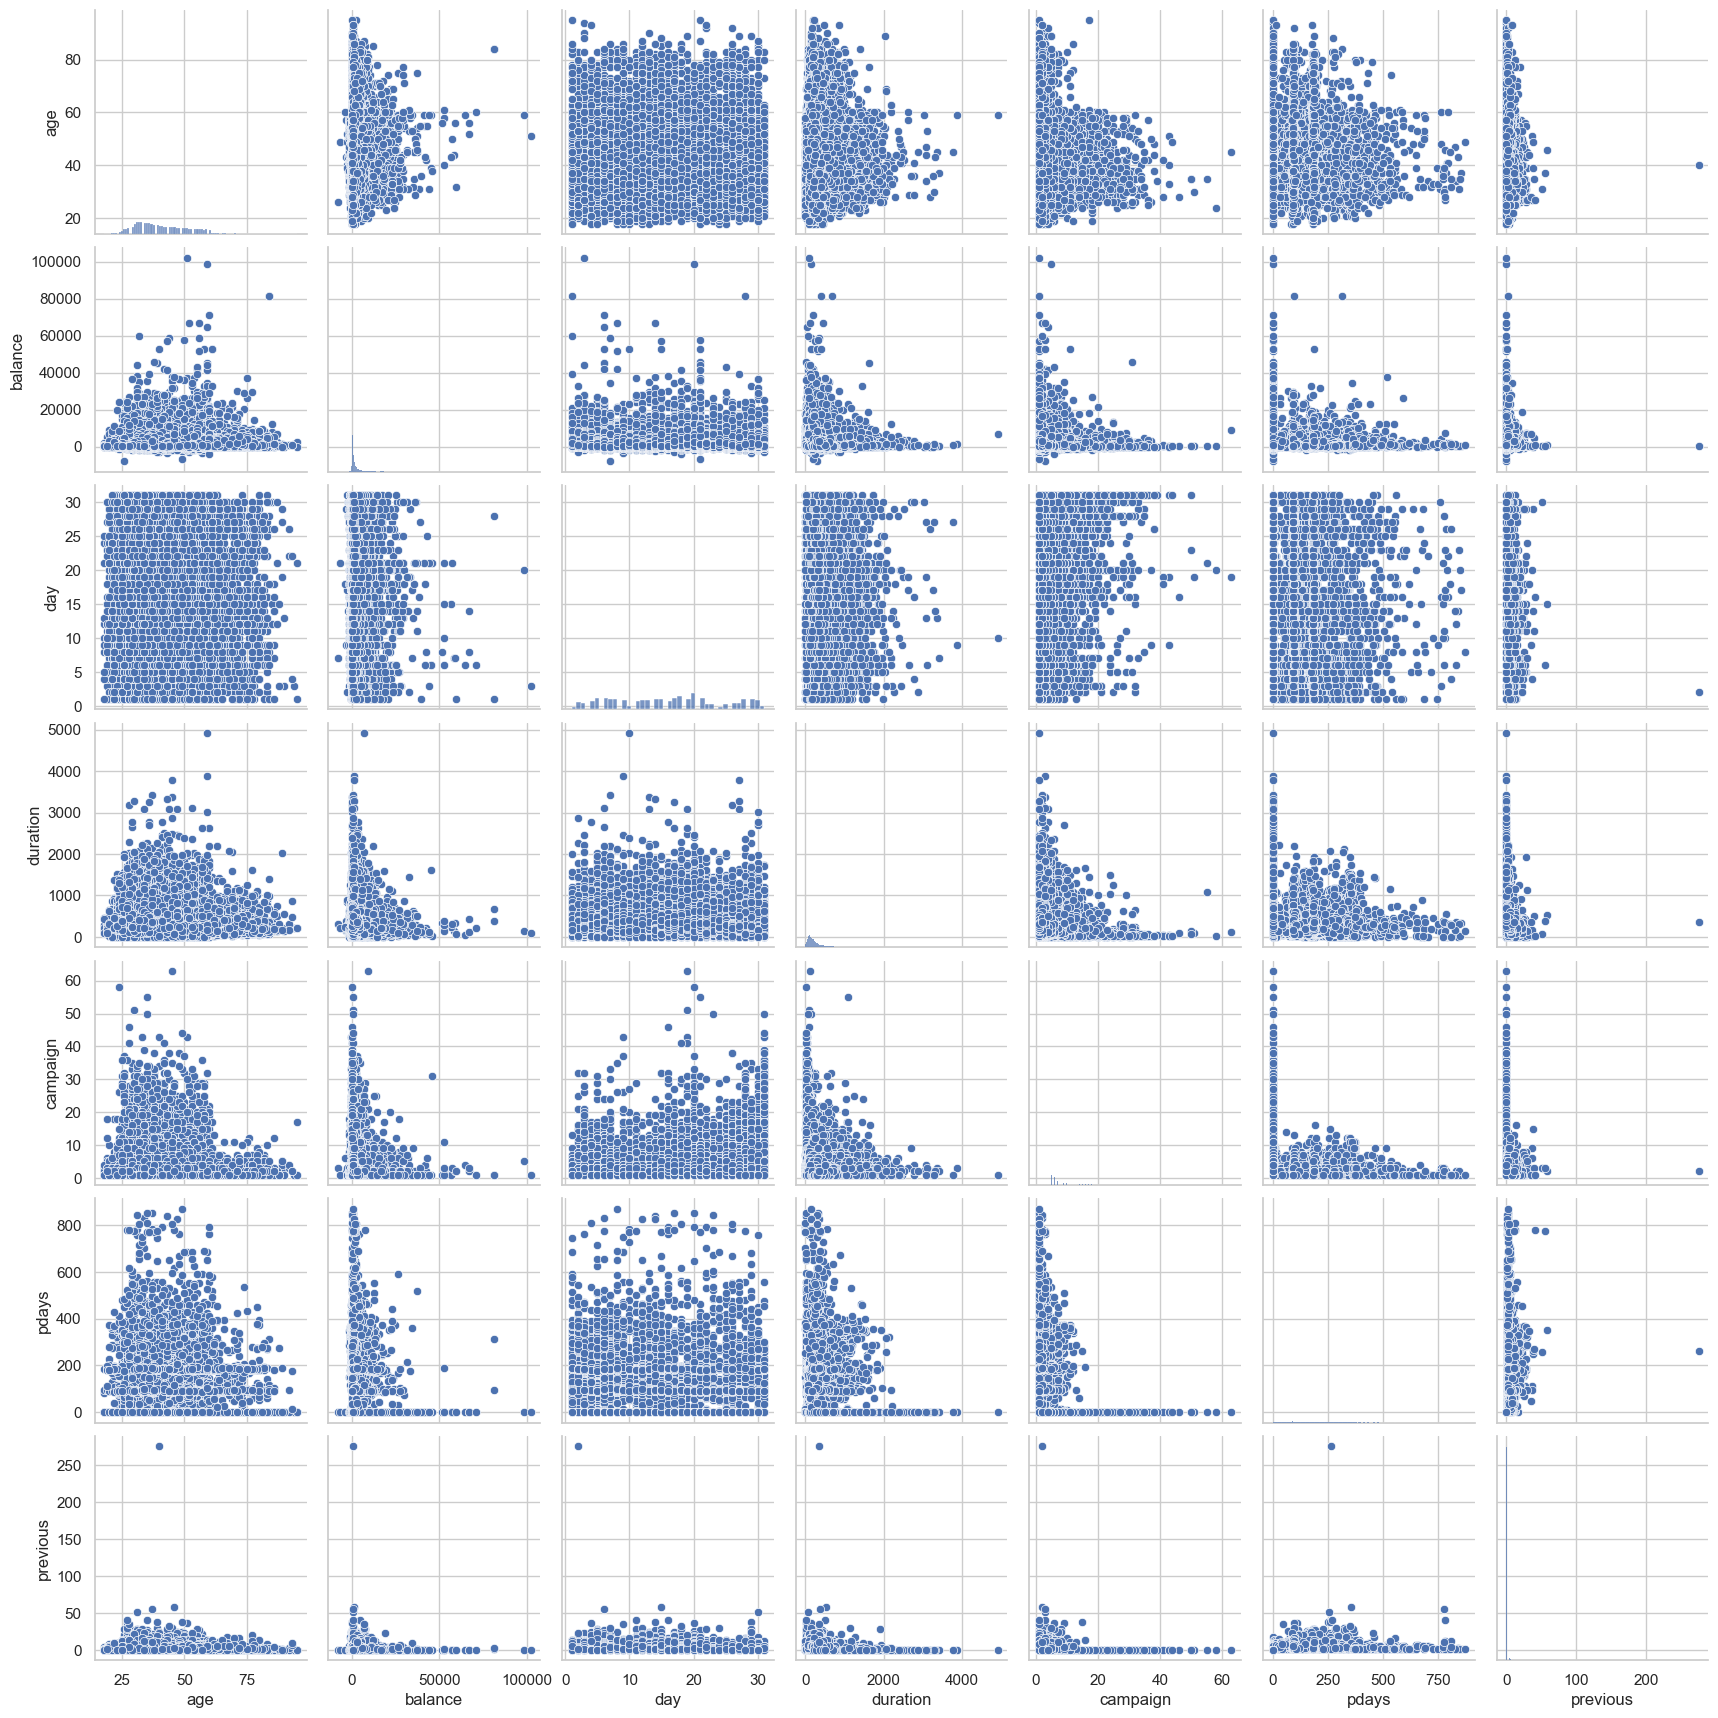


FAST EDA COMPLETED


In [8]:
# Repeat the EDA for the training set to check for any differences

plt.rcParams["figure.figsize"] = (10, 5)

# =========================
# FAST EDA IN ONE CELL
# =========================

plt.rcParams["figure.figsize"] = (10, 5)

# ---- BASIC INFORMATION ----
print("="*60)
print("DATASET SHAPE")
print("="*60)
print(df.shape)

print("\n" + "="*60)
print("FIRST 5 ROWS")
print("="*60)
display(df.head())

print("\n" + "="*60)
print("DATA TYPES AND MISSING VALUES")
print("="*60)
display(df.info())

print("\n" + "="*60)
print("NUMERICAL SUMMARY")
print("="*60)
display(df.describe())

print("\n" + "="*60)
print("CATEGORICAL SUMMARY")
print("="*60)
cat_summary_cols = df.select_dtypes(include=["object", "category", "bool"]).columns
if len(cat_summary_cols) > 0:
    display(df[cat_summary_cols].describe())
else:
    print("No categorical columns found for describe(include='object').")

# ---- MISSING VALUES ----
print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0])

plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

# ---- NUMERICAL DISTRIBUTIONS ----
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.histplot(df[col].dropna(), kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")

    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

# ---- CATEGORICAL VARIABLES ----
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

# ---- CORRELATION MATRIX ----
if len(num_cols) > 1:
    plt.figure(figsize=(10, 8))
    corr = df[num_cols].corr()

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        square=True
    )
    plt.title("Correlation Matrix")
    plt.show()

# ---- PAIRPLOT ----
if len(num_cols) <= 10:
    sns.pairplot(df[num_cols].dropna())
    plt.show()

print("\n" + "="*60)
print("FAST EDA COMPLETED")
print("="*60)

### Pandera part

In [9]:
import pandera as pa
from pandera import Column, DataFrameSchema, Check

schema = DataFrameSchema({
    "age": Column(int, Check(lambda s: s >= 0), nullable=False),
    "job": Column(str, nullable=False),
    "marital": Column(str, nullable=False),
    "education": Column(str, nullable=False),
    "default": Column(str, nullable=False),
    "balance": Column(int, nullable=False),
    "housing": Column(str, nullable=False),
    "loan": Column(str, nullable=False),
    "contact": Column(str, nullable=False),
    "day": Column(int, Check(lambda s: (s >= 1) & (s <= 31)), nullable=False),
    "month": Column(str, Check(lambda s: s.isin(["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"])), nullable=False),
    "duration": Column(int, Check(lambda s: s >= 0), nullable=False),
    "campaign": Column(int, Check(lambda s: s >= 0), nullable=False),
    "pdays": Column(int, Check(lambda s: s >= -1), nullable=False),
    "previous": Column(int, Check(lambda s: s >= 0), nullable=False),
    "poutcome": Column(str, nullable=False),
    "y": Column(str, Check(lambda s: s.isin(["yes", "no"])), nullable=False)
})

try:
    validated_df = schema.validate(df_train)
    print("Data validation successful. No issues found.")
except pa.errors.SchemaErrors as e:
    print("Data validation failed with the following errors:")
    print(e.failure_cases)

    # Optionally, you can raise the exception to stop the execution
    # raise e


Data validation successful. No issues found.


/Users/jorgeinigo/Documents/Trabajo final/.venv/lib/python3.12/site-packages/pandera/_pandas_deprecated.py:143: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)


### Parquet

In [15]:
# Change csv to parquet for faster loading in the future
df_train.to_parquet("../data/bank-full-train.parquet", index=False, engine="pyarrow")
df_val.to_parquet("../data/bank-full-val.parquet", index=False, engine="pyarrow")
df_test.to_parquet("../data/bank-full-test.parquet", index=False, engine="pyarrow")

### Initialize a ML Flow

In [16]:
# Read the parquet files to confirm they were saved correctly
df_train_parquet = pd.read_parquet("../data/bank-full-train.parquet", engine="fastparquet")
df_val_parquet = pd.read_parquet("../data/bank-full-val.parquet", engine="fastparquet")
df_test_parquet = pd.read_parquet("../data/bank-full-test.parquet", engine="fastparquet")

X1 = df_train_parquet.drop(columns=["y"])
y1 = df_train_parquet["y"]

X2 = df_test_parquet.drop(columns=["y"])
y2 = df_test_parquet["y"]

In [24]:
# Load pytorch to adjust a nn with the same data
import torch
import torch.nn as nn
import torch.optim as optim

In [25]:
# Apply get_dummies to the categorical columns when building tensors for pytorch
X_train_df = X1.select_dtypes(include=np.number)  # Keep only numerical columns for simplicity
X_train_df = pd.get_dummies(X_train_df, drop_first=True)  # Convert categorical to dummy variables
y_train_s = y1.map({"yes": 1, "no": 0})  # Convert target to binary

X_train_df.head()


,age,balance,day,duration,campaign,pdays,previous
0,40,580,16,192,1,-1,0
1,47,3644,9,83,2,-1,0
2,25,538,20,226,1,-1,0
3,42,1773,9,311,1,336,1
4,56,217,21,121,2,-1,0


In [26]:
# Now with test data
X_test_df = X2.select_dtypes(include=np.number)  # Keep only numerical columns for simplicity
X_test_df = pd.get_dummies(X_test_df, drop_first=True)  # Convert categorical to dummy variables
y_test_s = y2.map({"yes": 1, "no": 0})  # Convert target to binary

X_test_df.head()


,age,balance,day,duration,campaign,pdays,previous
0,43,593,5,55,1,-1,0
1,41,270,5,222,1,-1,0
2,45,13,5,98,1,-1,0
3,56,779,5,164,1,-1,0
4,46,-246,5,255,2,-1,0


In [27]:
# Split train into 80-20 train-val, expecting a 60/20/20
from sklearn.model_selection import train_test_split
X_train_df, X_val_df, y_train_s, y_val_s = train_test_split(X_train_df, y_train_s, test_size=0.2, random_state=42)

# Apply StandardScaler to the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = torch.tensor(scaler.fit_transform(X_train_df), dtype=torch.float32)
X_val = torch.tensor(scaler.transform(X_val_df), dtype=torch.float32)
X_test = torch.tensor(scaler.transform(X_test_df), dtype=torch.float32)


In [28]:
# define a MLP model using NN.Module with three hidden layers, dropout and batchnorm, last layer without activation function

import torch.nn as nn

class MLP(nn.Module):

    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)
        self.dropout3 = nn.Dropout(0.5)
        self.fc4 = nn.Linear(32, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.bn1(x)
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.bn2(x)
        x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        x = self.bn3(x)
        x = self.dropout3(x)
        x = self.fc4(x)  # No activation function here
        return x

#### Entrenamiento

In [29]:

# Binary classification: BCEWithLogitsLoss (sigmoid + BCE, numerically stable)
# AdamW optimizer, 30 epochs, StepLR scheduler

def _to_float_tensor(x):
    """Convert pandas Series / numpy array / tensor to float32 tensor."""
    if isinstance(x, torch.Tensor):
        return x.float()
    val = x.values if hasattr(x, "values") else x
    return torch.tensor(val, dtype=torch.float32)

# Guarantee all inputs are proper tensors regardless of execution order
X_train_ = X_train if isinstance(X_train, torch.Tensor) else torch.tensor(X_train.values, dtype=torch.float32)
X_val_   = X_val   if isinstance(X_val,   torch.Tensor) else torch.tensor(X_val.values,   dtype=torch.float32)
X_test_  = X_test  if isinstance(X_test,  torch.Tensor) else torch.tensor(X_test.values,  dtype=torch.float32)
y_train_ = _to_float_tensor(y_train)
y_val_   = _to_float_tensor(y_val)
y_test_  = _to_float_tensor(y_test)

model = MLP(X_train_.shape[1])
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
num_epochs = 30

train_losses, val_losses = [], []

for epoch in range(num_epochs):
    # --- train ---
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_).squeeze()
    loss = criterion(outputs, y_train_)
    loss.backward()
    optimizer.step()
    scheduler.step()
    train_losses.append(loss.item())

    # --- validation ---
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_).squeeze()
        val_loss = criterion(val_outputs, y_val_)
    val_losses.append(val_loss.item())

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1:>2}/{num_epochs}]  "
              f"Train Loss: {loss.item():.4f}  |  Val Loss: {val_loss.item():.4f}")

print("\nTraining complete.")


Epoch [ 5/30]  Train Loss: 0.6841  |  Val Loss: 0.6319
Epoch [10/30]  Train Loss: 0.6540  |  Val Loss: 0.5939
Epoch [15/30]  Train Loss: 0.6470  |  Val Loss: 0.5756
Epoch [20/30]  Train Loss: 0.6482  |  Val Loss: 0.5652
Epoch [25/30]  Train Loss: 0.6490  |  Val Loss: 0.5615
Epoch [30/30]  Train Loss: 0.6508  |  Val Loss: 0.5605

Training complete.


In [30]:

# Evaluate on validation and test sets
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Helper: convert tensor → numpy via Python list (avoids torch/numpy ABI mismatch)
def t2np(tensor):
    return np.array(tensor.detach().tolist())

model.eval()
with torch.no_grad():
    # Validation
    val_logits  = model(X_val_).squeeze()
    val_loss    = criterion(val_logits, y_val_)
    val_probs   = t2np(torch.sigmoid(val_logits))
    val_preds   = (val_probs >= 0.5).astype(int)
    y_val_true  = t2np(y_val_).astype(int)

    print(f"Validation Loss    : {val_loss.item():.4f}")
    print(f"Validation Accuracy: {accuracy_score(y_val_true, val_preds):.4f}")
    print(f"Validation ROC-AUC : {roc_auc_score(y_val_true, val_probs):.4f}")

    print()

    # Test
    test_logits  = model(X_test_).squeeze()
    test_loss    = criterion(test_logits, y_test_)
    test_probs   = t2np(torch.sigmoid(test_logits))
    test_preds   = (test_probs >= 0.5).astype(int)
    y_test_true  = t2np(y_test_).astype(int)

    print(f"Test Loss          : {test_loss.item():.4f}")
    print(f"Test Accuracy      : {accuracy_score(y_test_true, test_preds):.4f}")
    print(f"Test ROC-AUC       : {roc_auc_score(y_test_true, test_probs):.4f}")
    print()
    print("Classification Report (test):")
    print(classification_report(y_test_true, test_preds, target_names=["no", "yes"]))


Validation Loss    : 0.5605
Validation Accuracy: 0.8448
Validation ROC-AUC : 0.8349

Test Loss          : 0.5571
Test Accuracy      : 0.8589
Test ROC-AUC       : 0.8502

Classification Report (test):
              precision    recall  f1-score   support

          no       0.94      0.89      0.92      3969
         yes       0.44      0.62      0.52       552

    accuracy                           0.86      4521
   macro avg       0.69      0.76      0.72      4521
weighted avg       0.88      0.86      0.87      4521



In [ ]:
from torchinfo import summary

# Initialize your model
input_dim = 20  # Example input size
model = MLP(input_dim)

# Print summary (Depth=2 shows internal details of blocks)
summary(model, input_size=(1, input_dim), col_names=["input_size", "output_size", "num_params", "kernel_size"], depth=2)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
MLP                                      [1, 20]                   [1, 1]                    --                        --
├─Linear: 1-1                            [1, 20]                   [1, 128]                  2,688                     --
├─BatchNorm1d: 1-2                       [1, 128]                  [1, 128]                  256                       --
├─Dropout: 1-3                           [1, 128]                  [1, 128]                  --                        --
├─Linear: 1-4                            [1, 128]                  [1, 64]                   8,256                     --
├─BatchNorm1d: 1-5                       [1, 64]                   [1, 64]                   128                       --
├─Dropout: 1-6                           [1, 64]                   [1, 64]                   --                        --
├─Linear: 1-7 

In [33]:
from torchview import draw_graph
import torch

model = MLP(input_dim=20)
batch_size = 2

# Generate the diagram
model_graph = draw_graph(model, input_size=(batch_size, 20), expand_nested=True)
model_graph.visual_graph.render("mlp_architecture", format="png") # Saves as mlp_architecture.png

'mlp_architecture.png'